In [145]:
import random
import statistics
import matplotlib.pyplot as plt
import numpy as np

def bootstrap(zdata,nreal,stat):
    zreal = []                            # declare an empty list to store the bootstrap realizations
    for l in range(0,nreal):              # loop over the L bootstrap realizations
        samples = random.choices(zdata, k=len(zdata)) # n Monte Carlo simulations, sample with replacement
        zreal.append(stat(samples))       # calculate the realization of the statistic and append to list
    return zreal                          # return the list of realizations of the statistic

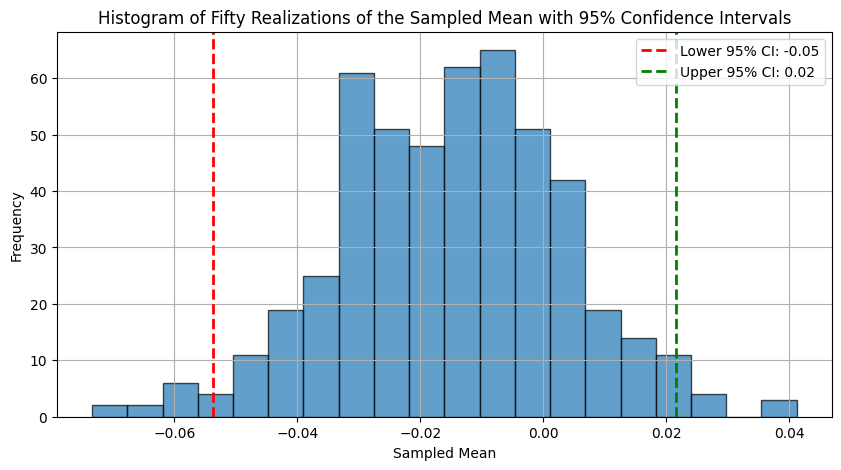

In [148]:
observed_samples = []
with open('delta_theta_uniform_initial.txt', 'r') as file:
    for line in file:
        num_strings = line.strip().split()
        nums = [round(float(num), 25) for num in num_strings]
        observed_samples.extend(nums)
fifty_realisations_sampled_mean = bootstrap(observed_samples, 50, statistics.mean)

# Calculate 95% confidence intervals
lower_bound = np.percentile(fifty_realisations_sampled_mean, 2.5)
upper_bound = np.percentile(fifty_realisations_sampled_mean, 97.5)

# 95% confidence interval 


# Plotting the histogram of the sampled means
plt.figure(figsize=(10, 5))
plt.hist(fifty_realisations_sampled_mean, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(lower_bound, color='red', linestyle='dashed', linewidth=2, label=f'Lower 95% CI: {lower_bound:.2f}')
plt.axvline(upper_bound, color='green', linestyle='dashed', linewidth=2, label=f'Upper 95% CI: {upper_bound:.2f}')
plt.title('Histogram of Fifty Realizations of the Sampled Mean with 95% Confidence Intervals')
plt.xlabel('Sampled Mean')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

In [143]:
import numpy as np
import pandas as pd

# Sample data
data = np.random.randn(50) * 10 + 75  # Example data with mean 75 and std 10

# Function to generate bootstrap samples
def bootstrap(data, num_samples):
    samples = np.random.choice(data, size=(num_samples, len(data)), replace=True)
    return samples

# Number of bootstrap samples
num_samples = 1000

# Generate bootstrap samples
bootstrap_samples = bootstrap(data, num_samples)

# Calculate mean and standard error for each bootstrap sample
means = np.mean(bootstrap_samples, axis=1)
std_errs = np.std(bootstrap_samples, axis=1) / np.sqrt(len(data))

# Calculate 95% confidence intervals for each bootstrap sample
conf_intervals = [(mean - 1.96 * se, mean + 1.96 * se) for mean, se in zip(means, std_errs)]

# Calculate proportion of intervals containing the population mean
true_mean = 75  # Assuming we know the true population mean for this example
coverage = sum(1 for lower, upper in conf_intervals if lower <= true_mean <= upper) / num_samples

print(f"Proportion of intervals containing the true mean: {coverage}")


Proportion of intervals containing the true mean: 0.852
